# Trabajo Práctico N°4 de TPS: LDA, QDA y KNN

En este trabajo práctico se aborda el problema de reconocimiento de rostros a partir de imágenes.
Se utiliza el dataset Olivetti Faces y se implementan desde cero los algoritmos LDA, QDA y KNN
para identificar la identidad de una persona a partir de su fotografía.

En primer lugar, se importan las librerías que se utilizarán a lo largo del mismo.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
try:
    from sklearn.datasets import fetch_olivetti_faces
    SKLEARN_AVAILABLE = True
except ImportError:
    SKLEARN_AVAILABLE = False

## Ítem A: Exploración de datos y split estratificado


En este inciso se realiza una primera exploración de la base de datos y se preparan los datos para los experimentos posteriores.
Se cargan las imágenes del dataset Olivetti Faces, se visualizan algunos ejemplos para entender su estructura y se construye
la partición de entrenamiento y testeo.


### Punto 1

Primero se comienza por cargar los datos desde sklearn si está disponible, y en caso contrario desde el archivo local `olivetti.npy`. Además, se extrae información básica del dataset para entender con qué se está trabajando antes de avanzar.

In [17]:
# --- PUNTO A.1: Cargar datos ---
if SKLEARN_AVAILABLE:
    dataset = fetch_olivetti_faces(shuffle=False)
    X = dataset.data        # shape: (400, 4096), píxeles aplanados
    y = dataset.target      # shape: (400,), etiquetas 0..39
    print("Datos cargados desde sklearn.")
else:
    data = np.load("../data/olivetti.npy", allow_pickle=True).item()
    X = data["data"]
    y = data["target"]
    print("Datos cargados desde olivetti.npy.")

# --- Exploración básica del dataset ---
n_imagenes      = X.shape[0]
n_pixeles       = X.shape[1]
lado_img        = int(np.sqrt(n_pixeles))   # 64
clases          = np.unique(y)
n_personas      = len(clases)
imgs_por_class  = np.array([np.sum(y == c) for c in clases])

print(f"\n{'='*45}")
print(f"  RESUMEN DEL DATASET OLIVETTI FACES")
print(f"{'='*45}")
print(f"  Total de imágenes        : {n_imagenes}")
print(f"  Número de personas       : {n_personas}")
print(f"  Imágenes por persona     : {imgs_por_class.min()} – {imgs_por_class.max()} (min–max)")
print(f"  Resolución de cada imagen: {lado_img} x {lado_img} px = {n_pixeles} features")
print(f"  Rango de valores de pixel: [{X.min():.3f}, {X.max():.3f}]")
print(f"  Tipo de dato             : {X.dtype}")
print(f"{'='*45}")

Datos cargados desde sklearn.

  RESUMEN DEL DATASET OLIVETTI FACES
  Total de imágenes        : 400
  Número de personas       : 40
  Imágenes por persona     : 10 – 10 (min–max)
  Resolución de cada imagen: 64 x 64 px = 4096 features
  Rango de valores de pixel: [0.000, 1.000]
  Tipo de dato             : float32


Del resumen anterior se pueden observar varias cosas relevantes:

- **Dataset perfectamente balanceado**: las 40 clases tienen exactamente 10 imágenes cada una. Esto es ideal porque ninguna clase "pesa" más que otra (ya que tenemos la misma cantidad de info para cada una), por lo que no se necesitan técnicas de balanceo.
- **Alta dimensionalidad con pocas muestras**: un aspecto importante de este *dataset* es que cada imagen tiene muchas características
(muchos píxeles) en comparación con la cantidad de datos disponibles. Esto implica que
hay pocas muestras para estimar correctamente la varianza del modelo.
- **Píxeles normalizados en [0, 1]**: como se ve en el rango impreso, sklearn ya divide los valores originales (0–255) por 255 al cargar el dataset. No se requiere preprocesamiento adicional de escala.
- **Tipo `float32`**: ocupa la mitad de memoria que `float64`. No afecta la lógica pero puede generar pequeños errores numéricos en operaciones como inversión de matrices si $\lambda$ es muy chico.

Una vez realizado este análisis inicial y comprendida mejor la estructura del dataset,
se grafican algunas imágenes seleccionadas al azar con el objetivo de visualizar los datos.


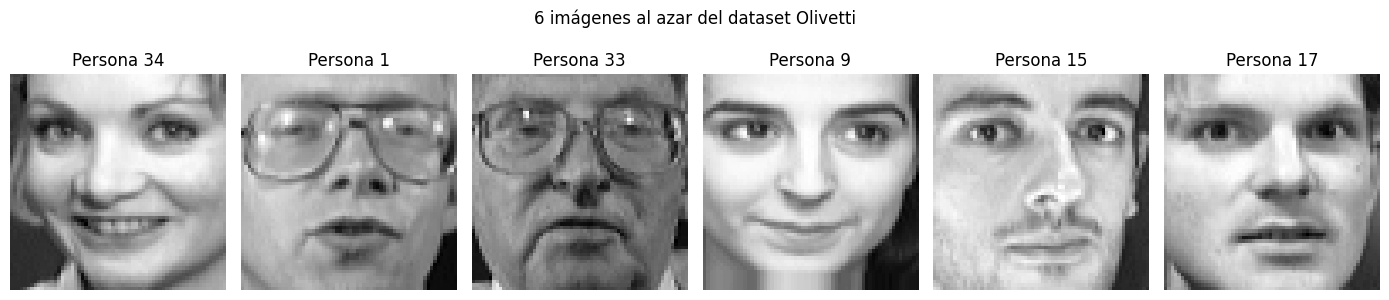

In [18]:
# Graficar 6 imágenes al azar
rng = np.random.default_rng()
indices = rng.choice(len(X), size=6, replace=False)

fig, axes = plt.subplots(1, 6, figsize=(14, 3))
for ax, idx in zip(axes, indices):
    ax.imshow(X[idx].reshape(64, 64), cmap="gray")
    ax.set_title(f"Persona {y[idx]}")
    ax.axis("off")
plt.suptitle("6 imágenes al azar del dataset Olivetti", y=1.02)
plt.tight_layout()
plt.show()

### Punto 2

Se separa la base de datos en entrenamiento (8 imágenes por persona) y testeo (2 imágenes por persona) de forma estratificada debido a:

- **Riesgo de clases vacías**: con solo 10 imágenes por persona, un split totalmente aleatorio podría dejar a alguien sin representación en test; o peor, con imágenes en test de alguien que el modelo nunca vio en entrenamiento.

- **La proporción entre clases no es algo que el modelo deba aprender**: si por azar la persona 3 termina con 9 imágenes en train y la persona 7 con solo 4, el modelo aprendería a "preferir" a la persona 3 simplemente por haberla visto más. Eso no refleja ninguna realidad del problema, es un artefacto del split. Como el dataset fue construido intencionalmente con 10 imágenes por persona, lo correcto es mantener esa uniformidad.

Por eso se garantiza que el split sea exactamente 8-2 para cada persona, no solo aproximadamente.

In [19]:
# --- PUNTO A.2: Split estratificado (2 imágenes por persona para test) ---
rng = np.random.default_rng(seed=0)

train_idx = []
test_idx  = []

for clase in np.unique(y):
    # índices de todas las imágenes de esta persona
    idx_clase = np.where(y == clase)[0]
    # elegir 2 al azar para test
    elegidos = rng.choice(idx_clase, size=2, replace=False)
    test_idx.extend(elegidos)
    # el resto va a train
    train_idx.extend([i for i in idx_clase if i not in elegidos])

train_idx = np.array(train_idx)
test_idx  = np.array(test_idx)

X_train, y_train = X[train_idx], y[train_idx]
X_test,  y_test  = X[test_idx],  y[test_idx]

print(f"Entrenamiento: {X_train.shape[0]} imágenes  ({X_train.shape[0]//40} por persona)")
print(f"Testeo:        {X_test.shape[0]}  imágenes  ({X_test.shape[0]//40} por persona)")

Entrenamiento: 320 imágenes  (8 por persona)
Testeo:        80  imágenes  (2 por persona)


Un dato importante es que a diferencia de la celda de visualización, acá sí se usa una semilla fija (`seed=0`). El split train/test determina qué tan bien le va a cada modelo, así que tiene que ser siempre el mismo: si cambiara en cada ejecución, los resultados de LDA, QDA y KNN no serían comparables entre sí, y tampoco podrían reproducirse por otra persona que corra el notebook.

## Ítem B: Linear Discriminant Analysis (LDA)

LDA es un clasificador generativo: en lugar de aprender directamente "¿esta imagen pertenece a la persona $k$?", aprende cómo son las imágenes de cada persona y después usa Bayes para inferir la identidad.



### Punto 1



#### ¿Qué aprende en entrenamiento?

Dado que tenemos 8 fotos de entrenamiento de cada persona, el LDA aprende dos cosas:

 **El rostro promedio de cada persona** $\hat{\mu}_k$

 Simplemente promedia las 8 imágenes. Es como una "foto número 9" borrosa que captura cómo es esa persona en general — la forma de la cara, la posición de los ojos, etc.

$$\hat{\mu}_k = \frac{1}{|D_k|}\sum_{x \in D_k} x$$

Donde $D_k$ es el conjunto de imágenes de entrenamiento que pertenecen a la persona $k$, como hay 8 fotos, $|D_k|=8$.

Cada $x$ es un vector de 4096 píxeles, la suma se hace píxel a píxel: el píxel 1 de las 8 fotos se promedia, el píxel 2 de las 8 fotos se promedia, y así. El resultado es una imagen donde cada píxel vale el promedio de ese mismo píxel en las 8 fotos de entrenamiento de esa persona.

**¿Por qué el promedio?** Si se asume que las fotos siguen una gaussiana centrada en $\mu_k$, el valor de $\mu_k$ que maximiza la probabilidad de haber observado esas 8 fotos (MLE) es siempre el promedio muestral — es el centro de la campana que mejor "cubre" los datos.

**La variabilidad típica de las fotos** $\hat{\Sigma}$

Además del promedio de cada persona, LDA necesita una forma de describir cómo suelen variar las fotos en general.
La idea no es capturar qué hace único a cada individuo, sino entender qué cambios son habituales en una imagen de rostro.

Para eso, primero se analiza cada persona por separado:
se mide cuánto varían sus propias fotos respecto a su propio promedio
(Juan con Juan, Pedro con Pedro, nunca entre personas distintas).
Esto da lugar a una matriz de covarianza por persona, $\hat{\Sigma}_k$,
que resume cambios típicos como iluminación, expresión o pequeñas variaciones de pose
dentro de esa misma persona.

Luego, todas estas matrices se combinan en una única matriz $\hat{\Sigma}$.
Como en este dataset todas las personas tienen la misma cantidad de fotos,
esta combinación es simplemente un promedio entre las covarianzas individuales.
De esta manera se obtiene una descripción global de la variabilidad típica de las imágenes.

La idea clave es que los factores que aparecen en todas las personas
(por ejemplo luz o expresión facial)
están presentes en cada $\hat{\Sigma}_k$ y, al promediarlas,
no se cancelan, sino que quedan reflejados en la matriz final.
En cambio, variaciones muy particulares de un solo individuo
tienden a diluirse y no dominan el modelo.

Formalmente, estas matrices se calculan como:

$$
\hat{\Sigma} = \frac{1}{n-K}\sum_{k=1}^{K}(|D_k|-1)\hat{\Sigma}_k,
\qquad
\hat{\Sigma}_k = \frac{1}{|D_k|-1}\sum_{x \in D_k}(x-\hat{\mu}_k)(x-\hat{\mu}_k)^T
$$

El supuesto clave de LDA es que todas las personas comparten la misma matriz de covarianza.
Esto implica que las diferencias entre clases se explican únicamente
a partir de sus promedios y no por la forma en la que varían sus imágenes.

Puede pensarse a LDA como un amplificador diferencial:
la matriz $\hat{\Sigma}$ modela la variación común presente en todas las caras
(lo que no ayuda a distinguir personas)
y el algoritmo la utiliza para atenuar ese “modo común”.
De esta forma, se resaltan únicamente las diferencias reales entre los promedios de cada persona,
que son las que permiten la clasificación.

Como consecuencia directa de este supuesto,
las fronteras de decisión entre clases resultan ser rectas (lineales).


---

#### ¿Por qué las fronteras son lineales? Derivación paso a paso

**Paso 1 — Aplicar Bayes**: queremos encontrar la persona más probable dada una imagen $x$:

$$P(k|x) \propto P(x|k) \cdot \underbrace{P(k)}_{c_k = \frac{8}{320} = \frac{1}{40}}$$

Donde $P(x|k)$ es ¿qué tan típica es $x$  para la persona $k$?

**Paso 2 — Asumir gaussiana**: las imágenes de cada persona se distribuyen como $x|Y=k \sim \mathcal{N}(\mu_k, \Sigma)$:

$$P(x|k) = \frac{1}{(2\pi)^{d/2}|\Sigma|^{1/2}} \exp\!\left(-\frac{1}{2}(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)\right)$$

**Paso 3 — Tomar logaritmo**: maximizar $P(k|x)$ es equivalente a maximizar su logaritmo:

$$\log P(k|x) \propto \log(c_k) - \frac{1}{2}(x-\mu_k)^T\Sigma^{-1}(x-\mu_k) - \underbrace{\frac{1}{2}\log|\Sigma|}_{\text{igual para todas las clases} \Rightarrow \text{se cancela}}$$

**Paso 4 — Expandir el producto cuadrático**:

$$(x-\mu_k)^T\Sigma^{-1}(x-\mu_k) = \underbrace{x^T\Sigma^{-1}x}_{\text{no depende de }k} - 2x^T\Sigma^{-1}\mu_k + \mu_k^T\Sigma^{-1}\mu_k$$

**Paso 5 — Cancelar lo que no depende de** $k$: el término $x^T\Sigma^{-1}x$ es el mismo para todas las clases, entonces no afecta cuál es la mayor. Se elimina.

**Resultado — la función discriminante lineal**:

$$\boxed{\tilde{\delta}_k(x) = x^T\tilde{\Sigma}^{-1}\mu_k + \log(c_k) - \frac{1}{2}\mu_k^T\tilde{\Sigma}^{-1}\mu_k}$$

- $x^T\tilde{\Sigma}^{-1}\mu_k$: similitud entre la imagen $x$ y el rostro promedio de la persona $k$, ponderada por $\tilde{\Sigma}^{-1}$ (los píxeles que varían poco entre fotos pesan más, porque son más informativos).
- $\log(c_k)$: el prior (acá igual para todos: $\log(1/40)$, así que no distingue entre clases).
- $-\frac{1}{2}\mu_k^T\tilde{\Sigma}^{-1}\mu_k$: constante de normalización por clase.

Es **lineal en** $x$ → las fronteras de decisión son hiperplanos. De ahí el nombre LDA.

Además, si comparamos dos clases Juan y Pedro, el modelo elige Juan cuando $\tilde{\delta}_{Juan} > \tilde{\delta}_{Pedro}$, es decir cuando:

$$x^T\tilde{\Sigma}^{-1}(\mu_{Juan} - \mu_{Pedro}) > \text{constante}$$

El término $(\mu_{Juan} - \mu_{Pedro})$ es exactamente la diferencia entre rostros — la información de "qué tan distintas son las personas entre sí" ya está implícita en la comparación.

---

La predicción **soft** (`predict_proba`) aplica softmax sobre los 40 puntajes $\tilde{\delta}_k(x)$ para obtener probabilidades. La predicción **hard** (`predict`) devuelve directamente la clase ganadora.



#### Implementación de la clase LDA
Se implementa la clase `LDA`. El hiperparámetro $\lambda$ controla la regularización de la covarianza. Se usa `float64` internamente para evitar errores numéricos en la inversión de la matriz.

In [20]:
class LDA:

    def __init__(self, lam=1e-2):
        """
        lam: factor de regularización λ para Σ̃ = Σ + λI.
             Necesario porque Σ es singular (p >> n).
        """
        self.lam = lam

    def fit(self, X, y):
        X = X.astype(np.float64)
        self.classes_ = np.unique(y)
        K = len(self.classes_)
        n, d = X.shape

        self.priors_ = np.zeros(K)
        self.means_  = np.zeros((K, d))
        Sigma = np.zeros((d, d))

        for i, k in enumerate(self.classes_):
            Xk = X[y == k]
            nk = len(Xk)
            self.priors_[i] = nk / n
            self.means_[i]  = Xk.mean(axis=0)
            diff = Xk - self.means_[i]           # (nk, d)
            Sigma += diff.T @ diff                # acumula (nk-1)*Σ_k

        # Covarianza pooled insesgada: Σ = 1/(n-K) * Σ_k (|Dk|-1)*Σ_k
        Sigma /= (n - K)

        # Regularización: Σ̃ = Σ + λI  (hace Σ invertible)
        self.Sigma_reg_ = Sigma + self.lam * np.eye(d)
        self.Sigma_inv_ = np.linalg.inv(self.Sigma_reg_)

        # Precomputar términos de la función discriminante por clase:
        # δ̃_k(x) = x^T Σ⁻¹ μ_k  +  log(c_k) - 0.5 * μ_k^T Σ⁻¹ μ_k
        #           ↑ término lineal  ↑ bias (constante por clase)
        self.W_    = self.means_ @ self.Sigma_inv_          # (K, d)
        self.bias_ = np.array([
            np.log(self.priors_[i]) - 0.5 * self.means_[i] @ self.Sigma_inv_ @ self.means_[i]
            for i in range(K)
        ])
        return self

    def predict_proba(self, X):
        """Predicción soft: probabilidad posterior de cada clase via softmax."""
        X = X.astype(np.float64)
        delta = X @ self.W_.T + self.bias_          # (n_samples, K)
        # Softmax numéricamente estable
        delta -= delta.max(axis=1, keepdims=True)
        exp_d = np.exp(delta)
        return exp_d / exp_d.sum(axis=1, keepdims=True)

    def predict(self, X):
        """Predicción hard: clase con mayor función discriminante."""
        X = X.astype(np.float64)
        delta = X @ self.W_.T + self.bias_
        return self.classes_[np.argmax(delta, axis=1)]

    def accuracy(self, X, y):
        """Proporción de predicciones correctas."""
        return np.mean(self.predict(X) == y)

    def sampling(self, n_samples=1):
        """
        Simula muestras sintéticas del modelo generativo.
        Para cada muestra: elige una clase k según c_k, luego samplea x ~ N(μ_k, Σ̃).
        """
        rng = np.random.default_rng()
        L = np.linalg.cholesky(self.Sigma_reg_)    # Σ̃ = L @ L^T
        d = self.means_.shape[1]
        samples, labels = [], []
        for _ in range(n_samples):
            k = rng.choice(len(self.classes_), p=self.priors_)
            z = rng.standard_normal(d)
            x = self.means_[k] + L @ z             # x ~ N(μ_k, Σ̃)
            samples.append(x)
            labels.append(self.classes_[k])
        return np.array(samples), np.array(labels)

#### Regularización de la matriz de covarianza

Para clasificar una imagen, LDA necesita calcular la inversa de la matriz de covarianza.
En la práctica, se trabaja con la matriz regularizada $\tilde{\Sigma}^{-1}$.
El problema es que, en este *dataset*, las imágenes tienen una dimensionalidad muy alta
($p = 4096$ píxeles), mientras que la cantidad de muestras de entrenamiento es mucho menor
($n = 320$ imágenes).

Esto implica que los datos no ocupan todo el espacio de dimensión 4096, sino que viven en
un subespacio de dimensión mucho menor (a lo sumo $n-1$). Como consecuencia, la matriz de
covarianza estimada $\hat{\Sigma}$ no puede tener rango completo: existen muchas direcciones
del espacio donde no hay variación observada. En términos matemáticos, esto hace que
$\hat{\Sigma}$ sea singular (su determinante es cero) y, por lo tanto, no invertible.

Para resolver este problema se introduce la regularización. En lugar de invertir
directamente $\hat{\Sigma}$, se define una matriz de covarianza regularizada:

$$
\tilde{\Sigma} = \hat{\Sigma} + \lambda I
$$

Sumar $\lambda I$ significa agregar $\lambda$ a cada elemento de la diagonal de la matriz.
Dado que la diagonal de la matriz de covarianza representa la varianza de cada píxel,
esta operación puede interpretarse como asumir que ninguna dirección del espacio tiene
varianza exactamente cero, incluso aquellas donde los datos no aportan información suficiente.
En otras palabras, se impone una varianza mínima $\lambda$ en todas las direcciones.

Esto tiene un efecto geométrico claro: se evita asignar pesos infinitos a direcciones mal
estimadas al calcular la inversa de la covarianza. Sin regularización, pequeñas fluctuaciones
numéricas o ruido en direcciones poco observadas podrían ser amplificadas de manera extrema,
volviendo al clasificador inestable. Con regularización, estas direcciones siguen teniendo
peso, pero de forma acotada y controlada.

Formalmente, la regularización garantiza que la matriz sea invertible:

$$
\tilde{\Sigma} = \hat{\Sigma} + \lambda I
\quad \Longrightarrow \quad
\tilde{\Sigma}^{-1} \text{ existe siempre que } \lambda > 0
$$

El rol de $\lambda$ es análogo al de la regularización utilizada en regresión polinómica:
no elimina direcciones del espacio, sino que evita confiar ciegamente en estructuras mal
estimadas debido a la falta de datos. Valores pequeños de $\lambda$ estabilizan la inversión
sin distorsionar significativamente la covarianza observada.


Es importante notar que, aunque para direcciones regularizadas la inversa de la varianza
pueda tomar valores grandes cuando $\lambda$ es pequeño, esto no implica necesariamente
que dichas direcciones dominen la decisión. Para que una dirección influya en la
clasificación, no solo debe tener un peso grande en $\tilde{\Sigma}^{-1}$, sino que
también debe existir una diferencia significativa entre las clases al proyectar los datos
en esa dirección. En las direcciones donde la varianza es casi nula, los datos y los
promedios de las clases apenas varían, por lo que su contribución efectiva al criterio de
clasificación es muy baja. En teoría, podría ser problemático el caso de una dirección con
varianza muy pequeña pero con grandes diferencias entre clases; sin embargo, este escenario
es poco habitual en la práctica, ya que una diferencia discriminante fuerte suele venir
acompañada de variación observable en los datos. La regularización permite entonces limitar
la influencia de direcciones mal estimadas sin eliminar información relevante.
x

El valor $\lambda = 10^{-2}$ es una elección arbitraria inicial — simplemente un número chico que permite partir y ver cómo funciona el modelo. En QDA se analizará más formalmente cómo elegir $\lambda$ antes de entrenar.

### Puntos 2, 3 y 4

Se entrena el LDA con los datos de entrenamiento y se evalúa sobre el conjunto de testeo.

In [26]:
# --- PUNTO B.2: Entrenar LDA ---
lda = LDA(lam=1e-2)
lda.fit(X_train, y_train)
print("LDA entrenado.")

# --- PUNTO B.3: Accuracy de testeo ---
acc_test  = lda.accuracy(X_test,  y_test)
acc_train = lda.accuracy(X_train, y_train)
print(f"Accuracy train : {acc_train:.2%}")
print(f"Accuracy test  : {acc_test:.2%}")

LDA entrenado.
Accuracy train : 100.00%
Accuracy test  : 100.00%


In [27]:
# --- Verificación: distintas semillas y distintos λ ---
seeds  = [0, 1, 2, 3, 4]
lambdas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]

print(f"{'seed':>5}  {'λ':>8}  {'train':>8}  {'test':>8}")
print("-" * 38)
for s in seeds:
    # split con esta semilla
    rng_s = np.random.default_rng(seed=s)
    tr_idx, te_idx = [], []
    for clase in np.unique(y):
        idx_c = np.where(y == clase)[0]
        eleg  = rng_s.choice(idx_c, size=2, replace=False)
        te_idx.extend(eleg)
        tr_idx.extend([i for i in idx_c if i not in eleg])
    Xtr, ytr = X[np.array(tr_idx)], y[np.array(tr_idx)]
    Xte, yte = X[np.array(te_idx)],  y[np.array(te_idx)]

    for lam in lambdas:
        m = LDA(lam=lam).fit(Xtr, ytr)
        print(f"{s:>5}  {lam:>8.0e}  {m.accuracy(Xtr,ytr):>7.1%}  {m.accuracy(Xte,yte):>7.1%}")

 seed         λ     train      test
--------------------------------------
    0     1e-04   100.0%   100.0%
    0     1e-03   100.0%   100.0%
    0     1e-02   100.0%   100.0%
    0     1e-01   100.0%   100.0%
    0     1e+00    99.1%    97.5%
    1     1e-04   100.0%    98.8%
    1     1e-03   100.0%    98.8%
    1     1e-02   100.0%    98.8%
    1     1e-01   100.0%    98.8%
    1     1e+00    99.7%    97.5%
    2     1e-04   100.0%    96.2%
    2     1e-03   100.0%    96.2%
    2     1e-02   100.0%    97.5%
    2     1e-01   100.0%    97.5%
    2     1e+00   100.0%    95.0%
    3     1e-04   100.0%    97.5%
    3     1e-03   100.0%    97.5%
    3     1e-02   100.0%    98.8%
    3     1e-01   100.0%    98.8%
    3     1e+00   100.0%    97.5%
    4     1e-04   100.0%    96.2%
    4     1e-03   100.0%    96.2%
    4     1e-02   100.0%    96.2%
    4     1e-01   100.0%    97.5%
    4     1e+00   100.0%    92.5%


#### Las "fotos número 9": los rostros promedio aprendidos por LDA

Podemos visualizar directamente lo que aprendió el modelo durante el entrenamiento: el $\hat{\mu}_k$ de cada persona. Es el promedio de sus 8 fotos de entrenamiento — lo que LDA usa como "representante" de esa persona.

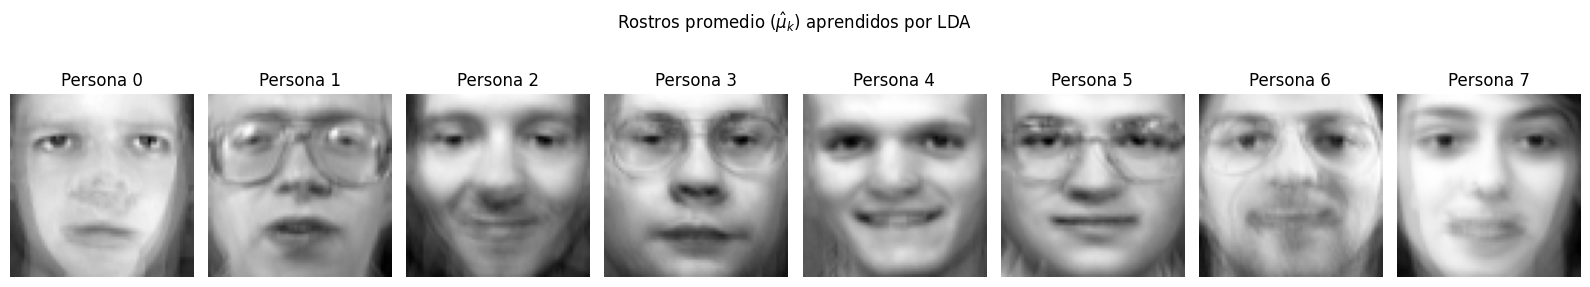

In [22]:
# Mostrar las "fotos 9": rostro promedio de las primeras 8 personas
n_mostrar = 8
fig, axes = plt.subplots(1, n_mostrar, figsize=(16, 3))
for i, ax in enumerate(axes):
    ax.imshow(lda.means_[i].reshape(64, 64), cmap="gray")
    ax.set_title(f"Persona {i}")
    ax.axis("off")
plt.suptitle("Rostros promedio ($\\hat{\\mu}_k$) aprendidos por LDA", y=1.02)
plt.tight_layout()
plt.show()

#### La varianza compartida: qué zonas de la cara varían más entre fotos

La diagonal de $\hat{\Sigma}$ indica la varianza de cada píxel a través de todo el dataset. Los píxeles con alta varianza (zonas brillantes en el mapa) cambian mucho entre fotos — son menos informativos para identificar a alguien. Los de baja varianza (zonas oscuras) son consistentes — son los que realmente distinguen a una persona de otra.

Cuando el modelo calcula $x^T \tilde{\Sigma}^{-1} \mu_k$, la inversión de $\Sigma$ hace exactamente eso: **pesa más los píxeles consistentes y menos los variables**.

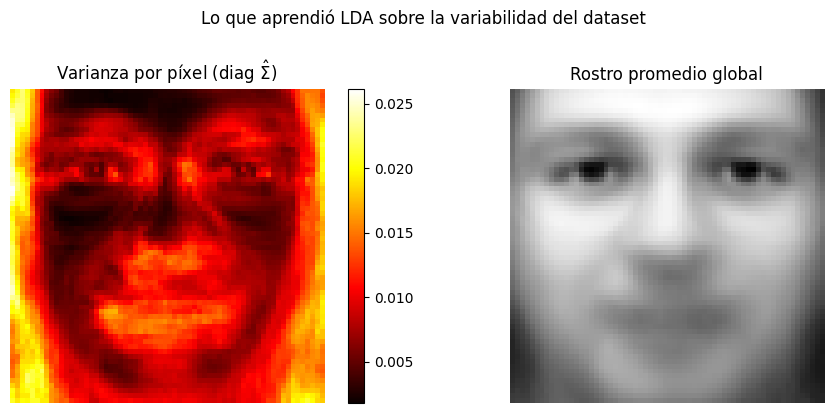

In [23]:
# La diagonal de Σ = varianza de cada píxel en el dataset
varianza_pixeles = np.diag(lda.Sigma_reg_ - lda.lam * np.eye(lda.Sigma_reg_.shape[0]))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Mapa de varianza
im = axes[0].imshow(varianza_pixeles.reshape(64, 64), cmap="hot")
axes[0].set_title("Varianza por píxel (diag $\\hat{\\Sigma}$)")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0])

# Foto promedio global (promedio de todos los μ_k)
media_global = lda.means_.mean(axis=0)
axes[1].imshow(media_global.reshape(64, 64), cmap="gray")
axes[1].set_title("Rostro promedio global")
axes[1].axis("off")

plt.suptitle("Lo que aprendió LDA sobre la variabilidad del dataset", y=1.02)
plt.tight_layout()
plt.show()

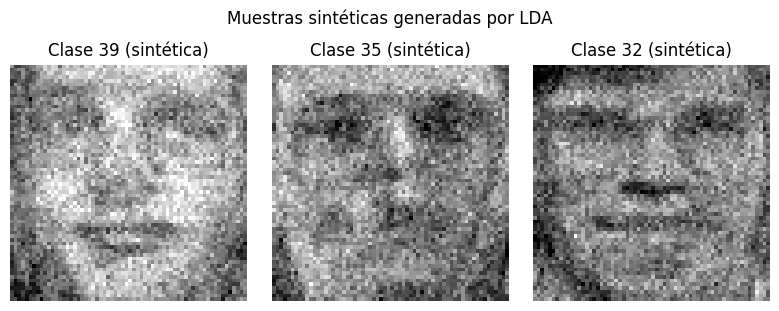

In [24]:
# --- PUNTO B.4: Simular 3 muestras sintéticas y graficarlas ---
muestras, etiquetas = lda.sampling(n_samples=3)

fig, axes = plt.subplots(1, 3, figsize=(8, 3))
for ax, img, lbl in zip(axes, muestras, etiquetas):
    # Clipear a [0,1] ya que la Gaussiana puede generar valores fuera del rango
    ax.imshow(np.clip(img, 0, 1).reshape(64, 64), cmap="gray")
    ax.set_title(f"Clase {lbl} (sintética)")
    ax.axis("off")
plt.suptitle("Muestras sintéticas generadas por LDA", y=1.02)
plt.tight_layout()
plt.show()